In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
import xarray as xr
import geopandas as gpd
import rioxarray as rxr
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from plotnine import (ggplot, aes, geom_point, geom_vline, geom_hline,
                      geom_rect, scale_fill_manual, scale_color_manual,
                      scale_shape_manual, labs, theme_bw, theme)


In [ ]:
class DataLoader:
    ''' Class for loading climate data from differen sources and bring them in the desired format.
    For adding new methods: The result should be a xarray timeseries for your area of interest,
    for one scenario/model/variable combination.'''

    def crop_to_park_boundary(self, nc, boundary, variable):
        ''' Takes an xarray object and crops within the provided boundary (geopandas), returning a clipped xarray object. '''
        # Select just the variable (time_bnds doesn't have spatial dims)
        nc = nc[variable].rio.set_spatial_dims(x_dim="lon", y_dim="lat")
        nc = nc.rio.write_crs("EPSG:4326", inplace=True)
        if nc.rio.crs != boundary.crs:
            boundary = boundary.to_crs(nc.rio.crs)
        nc_clipped = nc.rio.clip(boundary.geometry.values, boundary.crs, drop=True, all_touched=True)

        return(nc_clipped)

    def load_isimip(self, scenario, model, variable, boundary):
        ''' Loads data from ISIMIP 3b. This data has alsoready been downloaded, and cropped to the area of interest,
        using bash and CDO. The scripts are in this repository. The data is founds in isimip/data/processed'''
        nc = xr.open_dataset(f'isimip/data/processed/{model}_w5e5_{scenario}_{variable}_jotr_monthly.nc', engine="netcdf4")
        nc_clipped = self.crop_to_park_boundary(nc, boundary, variable).mean(("lon", "lat"))

        return nc_clipped

    def load_loca2(self, scenario, model, variable, boundary, data_root):
        ''' Loads LOCA2 yearly NetCDF files.
        Normalises 0–360 longitudes to -180/180, clips to the park boundary,
        converts plain-int year coordinates to datetime64 so that
        .sel(time=slice("YYYY","YYYY")) works consistently, and applies unit conversions. '''
        data_root = Path(data_root)
        matches = sorted(data_root.glob(f"{model}/{scenario}/{variable}/*.nc"))
        if not matches:
            raise FileNotFoundError(f"No LOCA2 file found for {model}/{scenario}/{variable}")

        ds = xr.open_dataset(matches[0], engine="netcdf4")
        var_name = list(ds.data_vars)[0]
        da = ds[var_name]

        # Normalise 0–360 lons → -180/180 to match EPSG:4326 boundary
        da = da.assign_coords(lon=((da.lon + 180) % 360) - 180)
        da = da.sortby("lon")

        # Clip to park boundary
        da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
        da = da.rio.write_crs("EPSG:4326", inplace=True)
        bnd = boundary.to_crs("EPSG:4326")
        clipped = da.rio.clip(bnd.geometry.values, bnd.crs, drop=True, all_touched=True)

        # Spatial mean → 1-D time series
        ts = clipped.mean(["lat", "lon"])

        # Normalise plain-int year coords (e.g. 1950, 1951 …) to datetime64        idx = ts.indexes["time"]
        if not hasattr(idx, "year"):
            ts = ts.assign_coords(
                time=pd.to_datetime([f"{int(y)}-07-01" for y in idx.values])
            )

        # Unit conversion: kg m-2 s-1 → mm/day
        if variable == "pr":
            ts = ts * 86400.0
            ts.attrs["units"] = "mm/day"

        ds.close()
        return ts


In [3]:
class ClimateFutures:
    ''' This class contains all the functions to create climate future datasets'''

    def __init__(self, models, scenarios, park, baseline_period, boundary_path=None,
                 precomputed_df=None, data_source='isimip', data_root=None, tas_variable='tas'):
        self.loader = DataLoader()
        self.models = models
        self.scenarios = scenarios
        self.park = park
        shp = boundary_path if boundary_path else f'boundaries/{park}.shp'
        self.boundary = gpd.read_file(shp)
        self.baseline_period = baseline_period
        self.precomputed_df = precomputed_df
        self.data_source = data_source
        self.data_root = data_root
        self.tas_variable = tas_variable

    def calculate_anomaly(self, scenario, baseline_period, model, variable, boundary):
        ''' Takes a clipped xarray object and calculates the anomaly relative to the provided baseline period. 
        Returns an xarray object of the anomaly. '''

        if self.data_source == 'loca2':
            nc = self.loader.load_loca2(scenario, model, variable, boundary, self.data_root)
            nc_hist = self.loader.load_loca2("historical", model, variable, boundary, self.data_root)
        else:
            nc = self.loader.load_isimip(scenario, model, variable, boundary)
            nc_hist = self.loader.load_isimip("historical", model, variable, boundary)

        baseline = nc_hist.sel(time=slice(baseline_period[0], baseline_period[1])).mean("time")
        anomaly = nc - baseline

        return(anomaly)

    def plot_timeseries(self, ax, scenario, model, baseline_period, boundary, variable, color=None):
        ''' Plot a single smoothed anomaly timeseries. color overrides the default scenario color. '''

        if color is None:
            if scenario == "historical":
                color = "#555555"  # dark grey
            elif scenario == "ssp126":
                color = "#ffd580"  # light orange
            elif scenario == "ssp370":
                color = "#ff9900"  # dark orange
            elif scenario == "ssp585":
                color = "#e95462"  # red
            else:
                color = "gray"

        anomaly = self.calculate_anomaly(scenario, baseline_period, model, variable, boundary)
        anomaly_smooth = anomaly.rolling(time=36, center=True, min_periods=1).mean()
        plot = anomaly_smooth.plot(ax=ax, label=f"{model.split('_')[0]} {scenario}", color=color, alpha=1)

        return(plot)

    def plot_ensemble(self, variable, color_map=None, include=None, xlim=None):
        ''' Plot all model/scenario timeseries.
        color_map: optional dict mapping (model, scenario) -> color.
                   If None, defaults to scenario-based colors.
        include: optional set of (model, scenario) pairs to plot.
                 If None, all model/scenario combinations are plotted.
        xlim: optional (start, end) tuple of year strings to set the x-axis range, e.g. ('1990', None). '''

        fig, ax = plt.subplots(figsize=(14, 6))

        for model in self.models:
            for scenario in self.scenarios:
                if include is not None and scenario != 'historical' and (model, scenario) not in include:
                    continue
                color = color_map.get((model, scenario)) if color_map else None
                self.plot_timeseries(ax, scenario, model, self.baseline_period,
                                     self.boundary, variable, color=color)

        if xlim is not None:
            ax.set_xlim(
                pd.Timestamp(xlim[0]) if xlim[0] else None,
                pd.Timestamp(xlim[1]) if xlim[1] else None
            )

        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.set_title(f'Anomaly (relative to 1979-2012) by Model and Scenario for {variable}')
        ax.set_ylabel('Anomaly')
        plt.tight_layout()
        plt.show()

    def plot_climate_futures(self, variable, futures=None):
        ''' Like plot_ensemble but lines are colored by climate future instead of scenario.
        futures: list of climate future labels to include, e.g. ['warm-wet', 'hot-dry'].
                 If None, all classified futures are shown. '''

        future_colors = {
            'warm-dry': '#fea973',
            'warm-wet': '#e95462',
            'hot-dry': '#331067',
            'hot-wet': '#b5367a',
            'central': 'gray'
        }

        df = self.classify()

        # Filter to only the requested futures (keep historical which has no future label)
        if futures is not None:
            df = df[df['climate_future'].isin(futures)]

        color_map = {
            (row['model'], row['scenario']): future_colors.get(row['climate_future'], 'gray')
            for _, row in df.iterrows()
        }

        # Only plot model/scenario pairs that are in the filtered set (plus historical)
        included = set(color_map.keys())
        self.plot_ensemble(variable, color_map=color_map, include=included, xlim=('1990', None))

    def mid_century_anomalies(self, scenario, baseline_period, model, variable, boundary):
        anomaly = self.calculate_anomaly(scenario, baseline_period, model, variable, boundary)
        mid_century_anomaly = anomaly.sel(time=slice("2035", "2065")).mean("time")

        return(mid_century_anomaly)

    def classify(self):
        # If anomalies were pre-computed externally, skip data loading
        all_data = []
        for model in self.models:
            for scenario in self.scenarios:
                if scenario == 'historical':
                    continue
                anomaly_tas = self.mid_century_anomalies(scenario, self.baseline_period, model, self.tas_variable, self.boundary)
                anomaly_pr = self.mid_century_anomalies(scenario, self.baseline_period, model, 'pr', self.boundary)
                data = {
                    'model': model,
                    'scenario': scenario,
                    'park': self.park,
                    'tas': anomaly_tas.item(),
                    'pr': anomaly_pr.item()
                }
                all_data.append(data)

        df = pd.DataFrame(all_data)

        quantiles = df[['tas', 'pr']].quantile([0.25, 0.5, 0.75])

        conditions = [
            # warm-dry
            ((df['tas'] < quantiles.loc[0.25, 'tas']) & (df['pr'] < quantiles.loc[0.50, 'pr'])) |
            ((df['tas'] < quantiles.loc[0.50, 'tas']) & (df['pr'] < quantiles.loc[0.25, 'pr'])),
            # warm-wet
            ((df['tas'] < quantiles.loc[0.25, 'tas']) & (df['pr'] > quantiles.loc[0.50, 'pr'])) |
            ((df['tas'] < quantiles.loc[0.50, 'tas']) & (df['pr'] > quantiles.loc[0.75, 'pr'])),
            # hot-dry
            ((df['tas'] > quantiles.loc[0.75, 'tas']) & (df['pr'] < quantiles.loc[0.50, 'pr'])) |
            ((df['tas'] > quantiles.loc[0.50, 'tas']) & (df['pr'] < quantiles.loc[0.25, 'pr'])),
            # hot-wet
            ((df['tas'] > quantiles.loc[0.75, 'tas']) & (df['pr'] > quantiles.loc[0.50, 'pr'])) |
            ((df['tas'] > quantiles.loc[0.50, 'tas']) & (df['pr'] > quantiles.loc[0.75, 'pr']))
        ]

        future = ['warm-dry', 'warm-wet', 'hot-dry', 'hot-wet']

        df['climate_future'] = np.select(conditions, future, default='central')

        return df

    def plot_quadrants(self):
        ''' Plots a climate futures quadrant scatter plot using plotnine.
        Scenario fill style is handled via separate geom_point layers:
          0 = filled (fill=climate_future color, black border)
          1 = hollow (no fill, colored border)
          2+ = double-ring (two hollow layers at different sizes)
        Plotnine's auto-legend is suppressed; a single combined matplotlib legend is built. '''

        future_colors = {
            'warm-dry': '#fea973',
            'warm-wet': '#e95462',
            'hot-dry': '#331067',
            'hot-wet': '#b5367a',
            'central': 'gray'
        }

        marker_pool = ['o', 's', '^', 'D', 'v', 'P', 'X']

        df = self.classify()
        df['model_short'] = df['model'].str.split('_').str[0]
        model_short_list = df['model_short'].unique().tolist()
        shape_map = {m: marker_pool[i % len(marker_pool)] for i, m in enumerate(model_short_list)}

        scenarios = [s for s in self.scenarios if s != 'historical']
        quantiles = df[['tas', 'pr']].quantile([0.25, 0.5, 0.75])

        iqr_box = pd.DataFrame({
            'xmin': [quantiles.loc[0.25, 'tas']],
            'xmax': [quantiles.loc[0.75, 'tas']],
            'ymin': [quantiles.loc[0.25, 'pr']],
            'ymax': [quantiles.loc[0.75, 'pr']]
        })

        # Base plot with reference lines and IQR box
        plot = (
            ggplot(df, aes(x='tas', y='pr'))
            + geom_rect(iqr_box, aes(xmin='xmin', xmax='xmax', ymin='ymin', ymax='ymax'),
                        fill='none', color='gray', linetype='dashed', size=0.8, inherit_aes=False)
            + geom_vline(xintercept=df['tas'].median(), color='gray', linetype='dashed')
            + geom_hline(yintercept=df['pr'].median(), color='gray', linetype='dashed')
        )

        # Add one geom_point layer per scenario to control fill style
        # Points are color-coded by climate future
        for i, scenario in enumerate(scenarios):
            subset = df[df['scenario'] == scenario].copy()
            if i == 0:
                # Filled: climate_future color fill, black border
                plot = plot + geom_point(
                    data=subset,
                    mapping=aes(x='tas', y='pr',
                                fill='climate_future', shape='model_short'),
                    color='black', size=4, stroke=0.8, inherit_aes=False
                )
            elif i == 1:
                # Hollow: no fill, colored border
                plot = plot + geom_point(
                    data=subset,
                    mapping=aes(x='tas', y='pr',
                                color='climate_future', shape='model_short'),
                    fill='none', size=4, stroke=1, inherit_aes=False
                )
            else:
                # Double-ring outer
                plot = plot + geom_point(
                    data=subset,
                    mapping=aes(x='tas', y='pr',
                                color='climate_future', shape='model_short'),
                    fill='none', size=4, stroke=0.8, inherit_aes=False
                )
                # Double-ring inner
                plot = plot + geom_point(
                    data=subset,
                    mapping=aes(x='tas', y='pr',
                                color='climate_future', shape='model_short'),
                    fill='none', size=1, stroke=0.8, inherit_aes=False
                )

        # Suppress plotnine's auto-legend; we'll build a clean matplotlib legend instead
        plot = (
            plot
            + scale_fill_manual(values=future_colors)
            + scale_color_manual(values=future_colors, guide=None)
            + scale_shape_manual(values=shape_map)
            + labs(x='Temperature Anomaly (K)', y='Precipitation Anomaly (mm/day)',
                   title=f'Climate Futures for {self.park.upper()}')
            + theme_bw()
            + theme(legend_position='none')
        )

        fig = plot.draw()
        ax = fig.axes[0]

        # Build a single combined matplotlib legend with section headers
        fill_labels = ['filled', 'hollow', 'double-ring']
        legend_handles = []

        # Climate Future section
        legend_handles.append(patches.Patch(facecolor='none', edgecolor='none',
                                            label='Climate Future'))
        for future, color in future_colors.items():
            legend_handles.append(patches.Patch(facecolor=color, edgecolor='k',
                                                label=f'  {future}'))

        # Model section
        legend_handles.append(patches.Patch(facecolor='none', edgecolor='none', label='Model'))
        for m, shape_char in shape_map.items():
            legend_handles.append(Line2D([0], [0], marker=shape_char, color='w',
                                         markerfacecolor='gray', markeredgecolor='k',
                                         markersize=8, label=f'  {m}'))

        # Scenario section
        legend_handles.append(patches.Patch(facecolor='none', edgecolor='none', label='Scenario'))
        for i, scenario in enumerate(scenarios):
            style = fill_labels[min(i, len(fill_labels) - 1)]
            fc = 'gray' if i == 0 else 'white'
            legend_handles.append(Line2D([0], [0], marker='o', color='w',
                                         markerfacecolor=fc, markeredgecolor='k',
                                         markersize=8, label=f'  {scenario} ({style})'))

        ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1),
                  fontsize=9, framealpha=1)

        return fig


## Canyonlands NP – LOCA2 Climate Futures

Anomalies were pre-computed in `canyonlands_futures.ipynb` and saved to `data/cany_anomalies.csv`.

getfattr: /workspaces/climate_futures/data/loca2_downloads/ACCESS-CM2/ssp245/tasmax/tasmax.ACCESS-CM2.ssp245.r1i1p1f1.2015-2044.LOCA_16thdeg_v20220413.yearly.s_west.nc: Operation not supported
getfattr: /workspaces/climate_futures/data/loca2_downloads/ACCESS-CM2/historical/tasmax/tasmax.ACCESS-CM2.historical.r1i1p1f1.1950-2014.LOCA_16thdeg_v20220413.yearly.s_west.nc: Operation not supported
getfattr: /workspaces/climate_futures/data/loca2_downloads/ACCESS-CM2/ssp585/tasmax/tasmax.ACCESS-CM2.ssp585.r1i1p1f1.2015-2044.LOCA_16thdeg_v20220413.yearly.s_west.nc: Operation not supported
getfattr: /workspaces/climate_futures/data/loca2_downloads/ACCESS-CM2/historical/tasmax/tasmax.ACCESS-CM2.historical.r1i1p1f1.1950-2014.LOCA_16thdeg_v20220413.yearly.s_west.nc: Operation not supported
getfattr: /workspaces/climate_futures/data/loca2_downloads/AWI-CM-1-1-MR/ssp245/tasmax/tasmax.AWI-CM-1-1-MR.ssp245.r1i1p1f1.2015-2044.LOCA_16thdeg_v20220413.yearly.s_west.nc: Operation not supported
getfattr: /wo

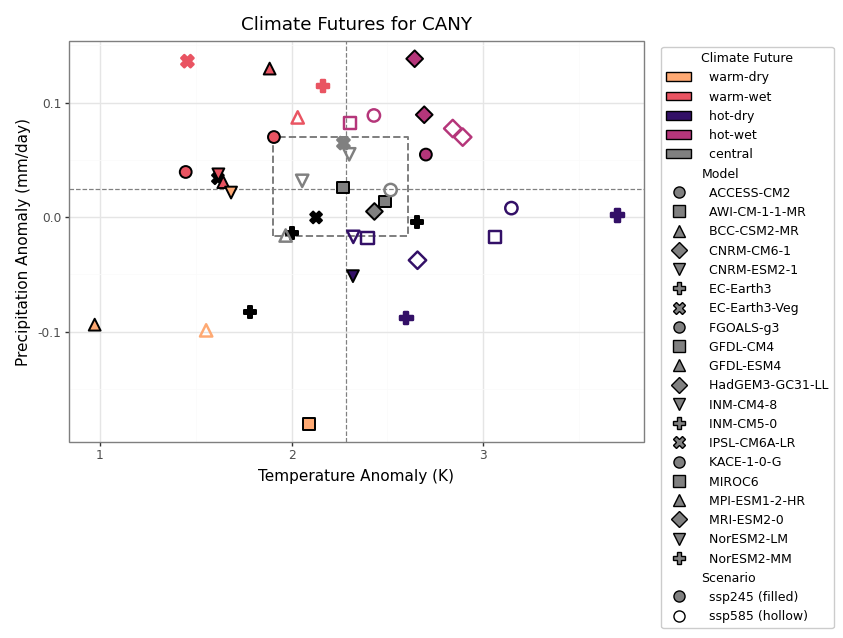

In [4]:


cf_cany = ClimateFutures(
    models=sorted([d.name for d in Path("data/loca2_downloads").iterdir() if d.is_dir()]),
    scenarios=["historical", "ssp245", "ssp585"],
    park="cany",
    baseline_period=("1981", "2010"),
    boundary_path="data/CANY-boundary/CANY_boundary.shp",
    data_source="loca2",
    data_root="data/loca2_downloads",
    tas_variable="tasmax",
)

cf_cany.plot_quadrants()
